# 2025-03-29 - Taxonomy

In this notebook, we will analyze the MMSeqs2 taxonomy results. Some of the questions that we hope to address here:
- Can we elaborate which bacteria class/families/order/genres/species are pressent in the sample?
- Can we use this tool to detect bacteria pathogens?

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm
import taxoniq
from seaborn import objects as so
import numpy as np
sns.set_style('ticks')
plt.rcParams['svg.fonttype'] = 'none'

## Reading data

The data is stored under different TSV files —one per library. Reading should be easy.

In [4]:
def load_library_taxonomy_results(file, path, library):
    """
    assigning labels from reading https://mmseqs.com/latest/userguide.pdf, taxonomy output and TSV
    """
    u = pd.read_csv(
        path + '/' + file, 
        sep='\t', 
        header=None, 
        index_col=None,
        names=['seq_id', 'taxid', 'level', 'species_name', 'fragments', 'frag_labeled', 'agreement', 'support']
    )
    u['library'] = library

    return u[['library', 'seq_id', 'taxid', 'level', 'species_name', 'fragments', 'support']]


In [5]:
load_library_taxonomy_results(
    "PV146.taxonomy.tsv", 
    "/home/bcz/research/miripvir25/results/2025-03-19-kraken2-mmseqs2-run",
    "PV146"
)

,library,seq_id,taxid,level,species_name,fragments,support
0,PV146,J00148:81:HNGTKBBXX:1:1118:19086:25597,0,no rank,unclassified,1,0.0
1,PV146,J00148:81:HNGTKBBXX:1:1119:12094:29765,0,no rank,unclassified,1,0.0
2,PV146,J00148:81:HNGTKBBXX:1:1117:11525:9543,0,no rank,unclassified,1,0.0
3,PV146,J00148:81:HNGTKBBXX:1:1118:14174:3125,0,no rank,unclassified,1,0.0
4,PV146,J00148:81:HNGTKBBXX:1:2108:16924:23048,2,superkingdom,Bacteria,2,1.0
...,...,...,...,...,...,...,...
65189,PV146,J00148:81:HNGTKBBXX:1:2211:17766:13324,0,no rank,unclassified,1,0.0
65190,PV146,J00148:81:HNGTKBBXX:1:2212:25540:2246,0,no rank,unclassified,1,0.0
65191,PV146,J00148:81:HNGTKBBXX:1:2209:11911:26529,2,superkingdom,Bacteria,2,1.0
65192,PV146,J00148:81:HNGTKBBXX:1:2210:11119:23962,2,superkingdom,Bacteria,2,1.0


In [6]:
input_reference = pd.read_csv("/home/bcz/research/miripvir25/results/2025-03-19-kraken2-mmseqs2-run/.input", header=None, names=["file"])
input_reference['library'] = input_reference['file'].apply(lambda x: 'PV{:03d}'.format(int(x.split('.')[0].replace('PV', ''))))
input_reference

,file,library
0,PV051.taxonomy.tsv,PV051
1,PV052.taxonomy.tsv,PV052
2,PV053.taxonomy.tsv,PV053
3,PV054.taxonomy.tsv,PV054
4,PV056.taxonomy.tsv,PV056
...,...,...
139,PV219.taxonomy.tsv,PV219
140,PV221.taxonomy.tsv,PV221
141,PV223.taxonomy.tsv,PV223
142,PV22.taxonomy.tsv,PV022


In [7]:
taxonomy_output = []
for i, row in tqdm.tqdm(list(input_reference.iterrows())):
    tmp = load_library_taxonomy_results(
        row.file, 
        "/home/bcz/research/miripvir25/results/2025-03-19-kraken2-mmseqs2-run",
        row.library
    )
    taxonomy_output.append(tmp)
taxonomy_output = pd.concat(taxonomy_output)
taxonomy_output

100%|██████████| 144/144 [00:17<00:00,  8.01it/s]


,library,seq_id,taxid,level,species_name,fragments,support
0,PV051,J00148:55:HN7NMBBXX:5:1208:12134:25509,0,no rank,unclassified,1,0.0
1,PV051,J00148:55:HN7NMBBXX:5:1209:19695:17966,2,superkingdom,Bacteria,2,1.0
2,PV051,J00148:55:HN7NMBBXX:5:1207:13464:1930,2,superkingdom,Bacteria,2,1.0
3,PV051,J00148:55:HN7NMBBXX:5:1208:17421:4004,0,no rank,unclassified,1,0.0
4,PV051,J00148:55:HN7NMBBXX:5:1208:16762:45695,0,no rank,unclassified,1,0.0
...,...,...,...,...,...,...,...
85163,PV002,J00148:23:HHTNKBBXX:7:1119:17188:37079,109099,species,Nesterenkonia sphaerica,2,1.0
85164,PV002,J00148:23:HHTNKBBXX:7:1117:17371:25931,0,no rank,unclassified,1,0.0
85165,PV002,J00148:23:HHTNKBBXX:7:2121:4229:17227,0,no rank,unclassified,1,0.0
85166,PV002,J00148:23:HHTNKBBXX:7:2122:19431:37238,0,no rank,unclassified,2,0.0


## Coverage 

How many sequences are we classifying? 
Once we know this fact, we can get rid of the unclassified sequences.

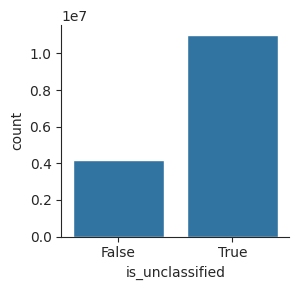

In [8]:
taxonomy_output['is_unclassified'] = taxonomy_output['taxid'] == 0
sns.catplot(
    taxonomy_output.value_counts(subset=['is_unclassified']).reset_index(), 
    x='is_unclassified', y='count', height=3.0, aspect=1.0, kind='bar'
)

Now we will get rid of those unclassified.

In [9]:
taxonomy_output = taxonomy_output.query('is_unclassified == False').copy()

## Taxonomic level assignments

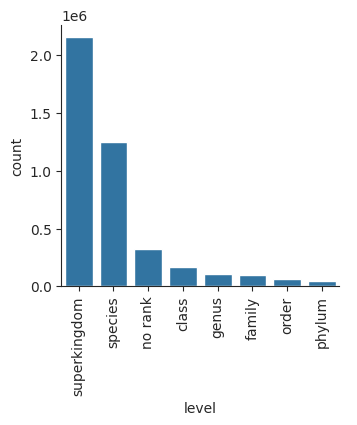

In [10]:
g = sns.catplot(
    data=taxonomy_output.value_counts(subset=['level']).reset_index(),
    x='level', y='count', kind='bar', height=3.5
)
g.set_xticklabels(rotation=90)

It seems that we recover quite a decent assignment

## Taxonomy assignments

GTDB taxonomy is a bit tricky, as it is different than the standard NCBI taxonomy codes. Indeed, the GTDB codes do not exist, they were created only for the purpose of GTDB mapping. Therefore, we need to work around this limitation.

In [11]:

class GTDB_taxonomy:

    def __init__(self, names, nodes):
        
        nodes = pd.read_csv(nodes, sep="\t\|\t", header=None, names=['taxid', 'parent', 'rank', '_'])[['taxid', 'parent', 'rank']]
        names = pd.read_csv(names, sep="\t\|\t", header=None, names=['taxid', 'scientific_name', '_', '__'])[['taxid', 'scientific_name']]
        nodes = pd.merge(nodes, names, on='taxid')
        nodes['t'] = nodes['taxid'].copy()
        self.nodes = nodes.set_index('t')
        self.parents = self.build_lineages_dict(nodes)

    @staticmethod
    def build_lineages_dict(nodes):
        parent_dict = dict()
        for _, node in nodes.iterrows():
            parent_dict[node.taxid] = node.parent
        return parent_dict

    def lineage(self, taxid):
        
        lineage = []
        
        lineage.append(self.nodes.loc[taxid].to_dict())
        max_depth = 20
        i = 0
        while lineage[-1]['taxid'] != 1 and i < max_depth:
            parent = self.nodes.loc[self.parents[taxid]].to_dict()
            lineage.append(parent)
            taxid = parent['taxid']
            i += 1
        return lineage

In [12]:
gtdbtax = GTDB_taxonomy(
    "../data/taxonomy/gtdb-taxdump/names.dmp",
    "../data/taxonomy/gtdb-taxdump/nodes.dmp"
)

/tmp/ipykernel_51320/3342168440.py:5: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  nodes = pd.read_csv(nodes, sep="\t\|\t", header=None, names=['taxid', 'parent', 'rank', '_'])[['taxid', 'parent', 'rank']]
/tmp/ipykernel_51320/3342168440.py:6: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  names = pd.read_csv(names, sep="\t\|\t", header=None, names=['taxid', 'scientific_name', '_', '__'])[['taxid', 'scientific_name']]


In [13]:
# taxonomy_reference = []
# for taxid in tqdm.tqdm(taxonomy_output.tax_id.unique()):
#     m = pd.DataFrame(gtdbtax.lineage(taxid))
#     m['taxid'] = taxid
#     m = m.pivot(index='taxid', columns='rank', values='scientific_name').reset_index()# .reset_index()
#     taxonomy_reference.append(m.loc[0].to_dict())

# taxonomy_reference = pd.DataFrame.from_records(taxonomy_reference)
# taxonomy_reference[['taxid', 'superkingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species']].to_json("../results/2025-03-19-kraken2-mmseqs2-run/gtdb-taxonomy-reference.json")

# 

In [14]:
taxonomy_reference = pd.read_json("../results/2025-03-19-kraken2-mmseqs2-run/gtdb-taxonomy-reference.json")

## Class assignments

We will be working at class level, for which goal we will proceed to remove all the samples that are not classified at rank class or lower.

In [15]:
taxonomy_output = pd.merge(taxonomy_output, taxonomy_reference, on='taxid')
taxonomy_output = taxonomy_output.dropna(subset='class').copy()

In [16]:
class_14 = taxonomy_output.value_counts(
    subset=['library', 'taxid', 'class']
).reset_index().groupby(
    ['class'], as_index=False
)['count'].sum().sort_values(
    by='count', ascending=False
)['class'].tolist()[:9]
taxonomy_output['class15'] = taxonomy_output['class'].apply(lambda x: x if x in class_14 else "Other")

## Sites assignments

Most of the downstream analysis that we aim to carry out depend on spatial assignments. We merge our dataset with a reference table that determines the sampling site.

In [17]:
mc24_table1 = pd.read_csv("/home/bcz/research/miripvir25/data/mcleish2024/nph20054-sup-0002-TablesS1.csv", sep=';')
mc24_table2 = pd.read_csv("/home/bcz/research/miripvir25/data/mcleish2024/nph20054-sup-0002-TablesS2.csv", sep=';')
mc24_table2 = mc24_table2.dropna(subset=['Library_code'])
mc24_table2['Collection_code'] = mc24_table2['Collection_code'].apply(lambda x: x.split("_")[0])
sample_reference = pd.merge(mc24_table1, mc24_table2, on='Collection_code').groupby(['Site_code', 'Collection_code', 'Library_code', 'Location', 'Host_taxon', 'Habitat', 'No_extracts'], as_index=False)['Date'].apply(lambda x: len(list(x)))
sample_reference

,Site_code,Collection_code,Library_code,Location,Host_taxon,Habitat,No_extracts,Date
0,C1,C1F,PV534,Aranjuez,Diplotaxis erucoides,Crop,3.0,1
1,C1,C1F,PV535,Aranjuez,Brassica oleracea,Crop,17.0,1
2,C1,C1F,PV538,Aranjuez,Brassica oleracea,Crop,8.0,1
3,C1,C1F,PV540,Aranjuez,Picris echioides,Crop,1.0,1
4,C1,C1F,PV544,Aranjuez,Sisymbrium runcinatum,Crop,4.0,1
...,...,...,...,...,...,...,...,...
318,Z1,Z1V,PV590,Villaconejos,Zea mays,Crop,11.0,1
319,Z2,Z2V,PV047,Villamanrique de Tajo,Zea mays,Crop,13.0,1
320,Z2,Z2V,PV048,Villamanrique de Tajo,Desconocida 4,Crop,9.0,1
321,Z2,Z2V,PV527,Villamanrique de Tajo,Convolvulus arvensis,Crop,4.0,1


In [18]:
taxonomy_output = pd.merge(taxonomy_output, sample_reference, left_on='library', right_on='Library_code')

### Class relative abundances

In [19]:
taxonomy_output_classcounts = taxonomy_output.value_counts(['Site_code', 'class15']).reset_index().sort_values(by='Site_code')
taxonomy_output_classtotalcounts = taxonomy_output.value_counts(['Site_code']).reset_index().sort_values(by='Site_code').rename(columns={'count': 'total'})
taxonomy_output_classcounts = pd.merge(taxonomy_output_classcounts, taxonomy_output_classtotalcounts, on='Site_code')
taxonomy_output_classcounts['AR'] = taxonomy_output_classcounts['count'] / taxonomy_output_classcounts['total']
taxonomy_output_classcounts.pivot(index='Site_code', columns='class15', values='AR')

class15,Acidimicrobiia,Actinomycetes,Alphaproteobacteria,Bacilli,Bacteroidia,Clostridia,Cyanobacteriia,Gammaproteobacteria,Other,Verrucomicrobiae
Site_code,,,,,,,,,,
E1,0.005594,0.165562,0.098784,0.072587,0.165000,0.121223,0.089152,0.136579,0.120316,0.025204
E2,0.008031,0.219428,0.106753,0.052728,0.087244,0.152667,0.062381,0.112188,0.177530,0.021050
E4,0.010286,0.107000,0.119882,0.037397,0.108216,0.146500,0.112192,0.185212,0.143313,0.030003
L1,0.009001,0.140813,0.104797,0.048098,0.183321,0.092212,0.068780,0.181546,0.125476,0.045957
L2,0.008265,0.159494,0.120480,0.042627,0.157343,0.087354,0.063871,0.169064,0.133068,0.058433
L3,0.016231,0.216718,0.123294,0.050069,0.160714,0.061657,0.056987,0.169224,0.119714,0.025393
L4,0.006969,0.128998,0.104265,0.069459,0.184253,0.109206,0.074173,0.118468,0.167021,0.037188
M1,0.005182,0.185035,0.102390,0.051731,0.104400,0.116060,0.070315,0.144918,0.190127,0.029841
M2,0.047209,0.201794,0.039793,0.011324,0.137799,0.028828,0.184968,0.102831,0.243022,0.002432


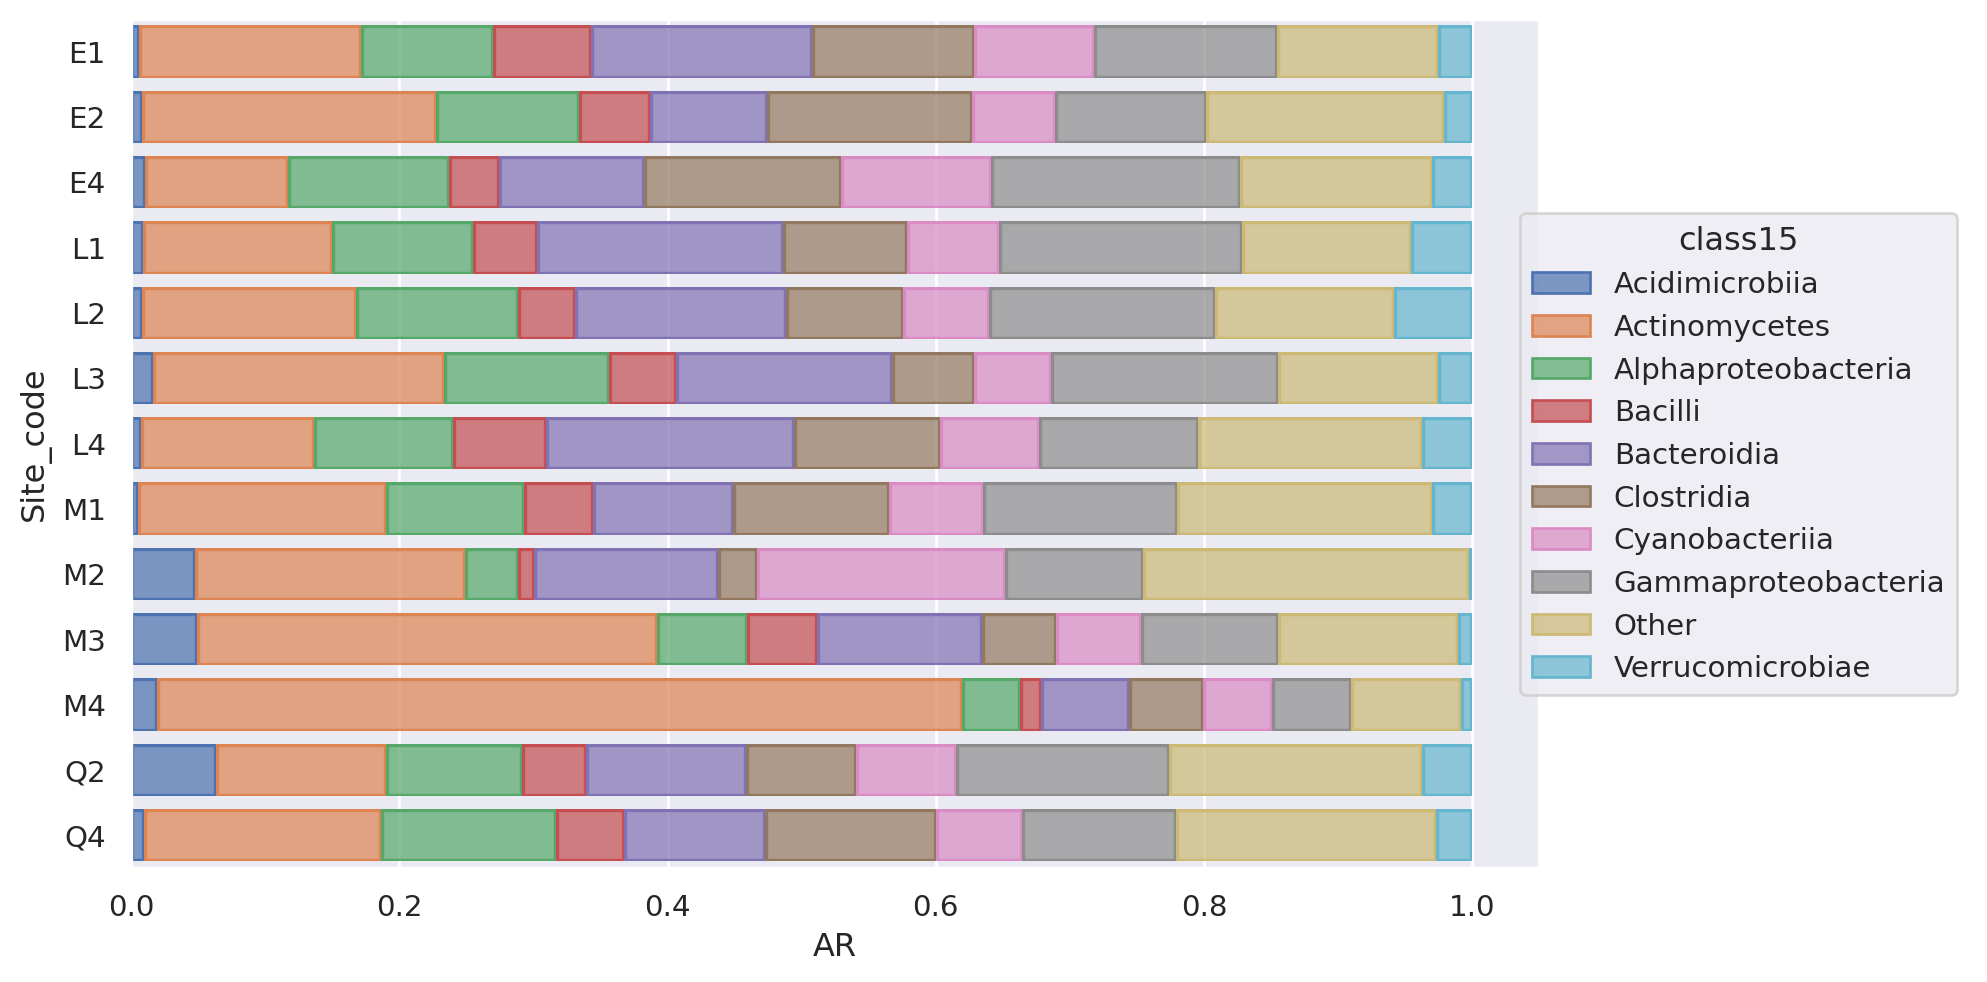

In [20]:
(
    so.Plot(
        data=taxonomy_output_classcounts.sort_values(by=['Site_code', 'class15']), 
        x="AR", y="Site_code", color="class15"
    ).add(
        so.Bar(), so.Stack()
    ).layout(
        size=(8,5), engine='constrained'
    )

)

In [21]:
from scipy.spatial.distance import braycurtis

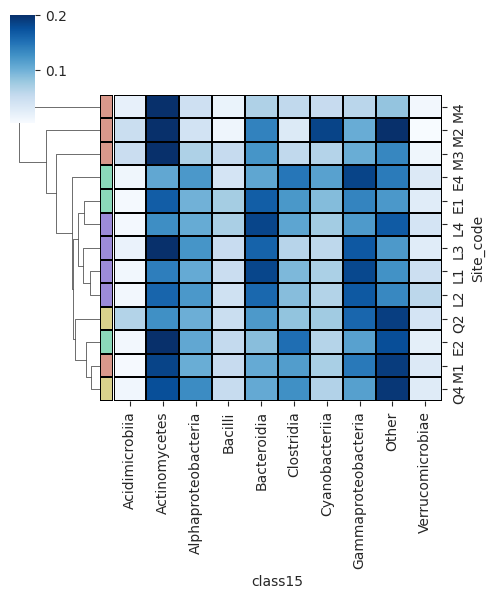

In [46]:
taxonomy_output_classcounts['lAR'] = taxonomy_output_classcounts['AR'].apply(lambda x: np.log10(x + 1e-6))
taxonomy_output_classcounts_pvt = taxonomy_output_classcounts.pivot(index='Site_code', columns='class15', values='AR')
site_codes = taxonomy_output_classcounts_pvt.reset_index()['Site_code']
habitat_dict = sample_reference.drop_duplicates(['Site_code'])[['Site_code', 'Habitat']].set_index('Site_code').to_dict()['Habitat']
habitats = [habitat_dict[item] for item in site_codes]

palette = {
    "Crop": "#D9988B", 
    "Edge": "#9C8BD9", 
    "Oak": "#DAD28C",
    "Wasteland": "#8BD9BA"
}

row_colors = [palette[item] for item in habitats]
g = sns.clustermap(
    taxonomy_output_classcounts_pvt, cmap='Blues', 
    figsize=(5, 6), metric=braycurtis, row_colors=row_colors, 
    col_cluster=False, linewidths=0.1, linecolor="black",vmax=0.2
)
g.savefig("../figures/gtdb-mmseqs2/class.clustermap.svg")

## Host role / average AR 

In [ ]:
taxonomy_output

,library,seq_id,taxid,level,species_name,fragments,support,is_unclassified,superkingdom,phylum,...,species,class15,Site_code,Collection_code,Library_code,Location,Host_taxon,Habitat,No_extracts,Date
0,PV051,J00148:55:HN7NMBBXX:5:1206:6532:11618,135553,species,JC017 sp004296775,4,0.6,False,Bacteria,Bacteroidota,...,JC017 sp004296775,Bacteroidia,Q4,Q4P,PV051,Mondéjar,Lotus corniculatus,Oak,13.0,2
1,PV051,J00148:55:HN7NMBBXX:5:2218:30066:28868,71277,species,RGIG9287 sp947165155,2,1.0,False,Bacteria,Bacillota A,...,RGIG9287 sp947165155,Clostridia,Q4,Q4P,PV051,Mondéjar,Lotus corniculatus,Oak,13.0,2
2,PV051,J00148:55:HN7NMBBXX:5:2219:7304:23892,135553,species,JC017 sp004296775,4,0.6,False,Bacteria,Bacteroidota,...,JC017 sp004296775,Bacteroidia,Q4,Q4P,PV051,Mondéjar,Lotus corniculatus,Oak,13.0,2
3,PV051,J00148:55:HN7NMBBXX:5:2224:9983:47348,55265,species,UBA9973 sp027347985,2,1.0,False,Bacteria,Patescibacteria,...,UBA9973 sp027347985,Other,Q4,Q4P,PV051,Mondéjar,Lotus corniculatus,Oak,13.0,2
4,PV051,J00148:55:HN7NMBBXX:5:2211:2138:26652,55151,species,Ferdinandcohnia aciditolerans,2,1.0,False,Bacteria,Bacillota,...,Ferdinandcohnia aciditolerans,Bacilli,Q4,Q4P,PV051,Mondéjar,Lotus corniculatus,Oak,13.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1679981,PV002,J00148:23:HHTNKBBXX:7:2222:6370:42706,79618,species,Streptomyces termitum,2,1.0,False,Bacteria,Actinomycetota,...,Streptomyces termitum,Actinomycetes,M1,M1V,PV002,Aranjuez,Convolvulus arvensis,Crop,11.0,1
1679982,PV002,J00148:23:HHTNKBBXX:7:2223:17888:43075,134412,species,Arthrobacter D sp002929355,4,1.0,False,Bacteria,Actinomycetota,...,Arthrobacter D sp002929355,Actinomycetes,M1,M1V,PV002,Aranjuez,Convolvulus arvensis,Crop,11.0,1
1679983,PV002,J00148:23:HHTNKBBXX:8:2118:20101:35339,44709,species,Flagellimonas alvinocaridis,2,0.5,False,Bacteria,Bacteroidota,...,Flagellimonas alvinocaridis,Bacteroidia,M1,M1V,PV002,Aranjuez,Convolvulus arvensis,Crop,11.0,1
1679984,PV002,J00148:23:HHTNKBBXX:8:2108:2341:1402,1004,genus,Nanosyncoccus,2,1.0,False,Bacteria,Patescibacteria,...,None,Other,M1,M1V,PV002,Aranjuez,Convolvulus arvensis,Crop,11.0,1


In [ ]:
taxonomy_output_hostrole_counts = taxonomy_output.value_counts(['library', 'Host_taxon', 'taxid']).reset_index().sort_values(by='library')
taxonomy_output_hostrole_totalcounts = taxonomy_output.value_counts(['library']).reset_index().sort_values(by='library').rename(columns={'count': 'total'})
taxonomy_output_hostrole_counts = pd.merge(taxonomy_output_hostrole_counts, taxonomy_output_hostrole_totalcounts, on='library')
taxonomy_output_hostrole_counts['AR'] = taxonomy_output_hostrole_counts['count'] / taxonomy_output_hostrole_counts['total']
taxonomy_output_hostrole_counts
# taxonomy_output_hostrole_counts.pivot(index='Library', columns='class15', values='AR')

,library,Host_taxon,taxid,count,total,AR
0,PV001,Amaranthus sp,137929,1,4079,0.000245
1,PV001,Amaranthus sp,5950,1,4079,0.000245
2,PV001,Amaranthus sp,14847,3,4079,0.000735
3,PV001,Amaranthus sp,5169,1,4079,0.000245
4,PV001,Amaranthus sp,110713,12,4079,0.002942
...,...,...,...,...,...,...
214292,PV223,Silybum marianum,19804,2,9848,0.000203
214293,PV223,Silybum marianum,19806,2,9848,0.000203
214294,PV223,Silybum marianum,23289,2,9848,0.000203
214295,PV223,Silybum marianum,17923,2,9848,0.000203


In [ ]:
taxonomy_output_hostrole_counts = pd.merge(taxonomy_output_hostrole_counts, taxonomy_output_hostrole_counts.value_counts(subset=['taxid', 'Host_taxon']).reset_index().value_counts('taxid').reset_index().rename(columns={'count':  'host_range'}), on='taxid')

In [ ]:
taxonomy_output_hostrole_counts

,library,Host_taxon,taxid,count,total,AR,host_range
0,PV001,Amaranthus sp,137929,1,4079,0.000245,3
1,PV001,Amaranthus sp,5950,1,4079,0.000245,19
2,PV001,Amaranthus sp,14847,3,4079,0.000735,3
3,PV001,Amaranthus sp,5169,1,4079,0.000245,48
4,PV001,Amaranthus sp,110713,12,4079,0.002942,66
...,...,...,...,...,...,...,...
214292,PV223,Silybum marianum,19804,2,9848,0.000203,2
214293,PV223,Silybum marianum,19806,2,9848,0.000203,4
214294,PV223,Silybum marianum,23289,2,9848,0.000203,43
214295,PV223,Silybum marianum,17923,2,9848,0.000203,1


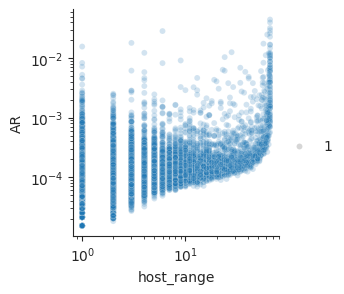

In [ ]:
g = sns.relplot(
    taxonomy_output_hostrole_counts.groupby('taxid')[['AR', 'host_range']].mean(), 
    x='host_range', y='AR', height=3.0, markers='.', alpha=0.2, size=1
)
g.axes[0, 0].set_yscale('log')
g.axes[0, 0].set_xscale('log')

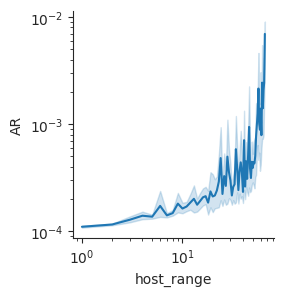

In [ ]:
g = sns.relplot(
    taxonomy_output_hostrole_counts.groupby('taxid')[['AR', 'host_range']].mean(), 
    x='host_range', y='AR', height=3.0, markers='.', alpha=1.0, kind='line'
)
g.axes[0, 0].set_yscale('log')
g.axes[0, 0].set_xscale('log')
g.savefig("../figures/gtdb-mmseqs2/host-range-ar.plot.svg")

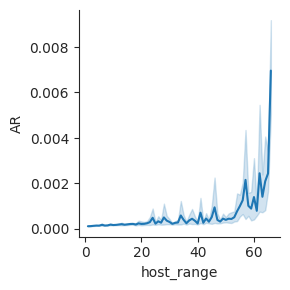

In [ ]:
g = sns.relplot(
    taxonomy_output_hostrole_counts.groupby('taxid')[['AR', 'host_range']].mean(), 
    x='host_range', y='AR', height=3.0, markers='.', alpha=1.0, kind='line'
)
# g.axes[0, 0].set_yscale('log')
# g.axes[0, 0].set_xscale('log')

## Co-ocurrence networks

In [ ]:
taxonomy_output

,library,seq_id,taxid,level,species_name,fragments,support,is_unclassified,superkingdom,phylum,...,species,class15,Site_code,Collection_code,Library_code,Location,Host_taxon,Habitat,No_extracts,Date
0,PV051,J00148:55:HN7NMBBXX:5:1206:6532:11618,135553,species,JC017 sp004296775,4,0.6,False,Bacteria,Bacteroidota,...,JC017 sp004296775,Bacteroidia,Q4,Q4P,PV051,Mondéjar,Lotus corniculatus,Oak,13.0,2
1,PV051,J00148:55:HN7NMBBXX:5:2218:30066:28868,71277,species,RGIG9287 sp947165155,2,1.0,False,Bacteria,Bacillota A,...,RGIG9287 sp947165155,Clostridia,Q4,Q4P,PV051,Mondéjar,Lotus corniculatus,Oak,13.0,2
2,PV051,J00148:55:HN7NMBBXX:5:2219:7304:23892,135553,species,JC017 sp004296775,4,0.6,False,Bacteria,Bacteroidota,...,JC017 sp004296775,Bacteroidia,Q4,Q4P,PV051,Mondéjar,Lotus corniculatus,Oak,13.0,2
3,PV051,J00148:55:HN7NMBBXX:5:2224:9983:47348,55265,species,UBA9973 sp027347985,2,1.0,False,Bacteria,Patescibacteria,...,UBA9973 sp027347985,Other,Q4,Q4P,PV051,Mondéjar,Lotus corniculatus,Oak,13.0,2
4,PV051,J00148:55:HN7NMBBXX:5:2211:2138:26652,55151,species,Ferdinandcohnia aciditolerans,2,1.0,False,Bacteria,Bacillota,...,Ferdinandcohnia aciditolerans,Bacilli,Q4,Q4P,PV051,Mondéjar,Lotus corniculatus,Oak,13.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1679981,PV002,J00148:23:HHTNKBBXX:7:2222:6370:42706,79618,species,Streptomyces termitum,2,1.0,False,Bacteria,Actinomycetota,...,Streptomyces termitum,Actinomycetes,M1,M1V,PV002,Aranjuez,Convolvulus arvensis,Crop,11.0,1
1679982,PV002,J00148:23:HHTNKBBXX:7:2223:17888:43075,134412,species,Arthrobacter D sp002929355,4,1.0,False,Bacteria,Actinomycetota,...,Arthrobacter D sp002929355,Actinomycetes,M1,M1V,PV002,Aranjuez,Convolvulus arvensis,Crop,11.0,1
1679983,PV002,J00148:23:HHTNKBBXX:8:2118:20101:35339,44709,species,Flagellimonas alvinocaridis,2,0.5,False,Bacteria,Bacteroidota,...,Flagellimonas alvinocaridis,Bacteroidia,M1,M1V,PV002,Aranjuez,Convolvulus arvensis,Crop,11.0,1
1679984,PV002,J00148:23:HHTNKBBXX:8:2108:2341:1402,1004,genus,Nanosyncoccus,2,1.0,False,Bacteria,Patescibacteria,...,None,Other,M1,M1V,PV002,Aranjuez,Convolvulus arvensis,Crop,11.0,1


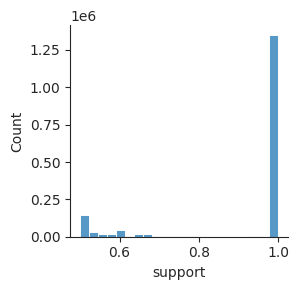

In [ ]:
sns.displot(data=taxonomy_output, x='support', height=3.0)

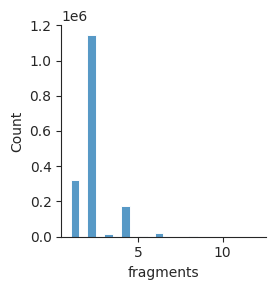

In [ ]:
sns.displot(data=taxonomy_output, x='fragments', height=3.0)

In [ ]:
import networkx as nx

In [ ]:
host_taxid_counts = taxonomy_output.query('class15 != "Other"').dropna(subset=['order']).query('support == 1.0').value_counts(subset=['Host_taxon', 'class', 'order']).reset_index()
host_taxid_counts['Lcount'] = host_taxid_counts['count'].apply(lambda x: np.log10(x))

In [ ]:
# host_taxid_counts = taxonomy_output.query('class15 != "Other"').query('support == 1.0').value_counts(subset=['Host_taxon', 'class']).reset_index()
# host_taxid_counts['Lcount'] = host_taxid_counts['count'].apply(lambda x: np.log10(x))
# host_taxid_counts

,Host_taxon,class,count,Lcount
0,Cynodon dactylon,Alphaproteobacteria,40882,4.611532
1,Conyza bonariensis,Actinomycetes,26351,4.420797
2,Diplotaxis erucoides,Bacteroidia,20785,4.317750
3,Geranium sp,Bacteroidia,20115,4.303520
4,Bromus sp,Gammaproteobacteria,16189,4.209220
...,...,...,...,...
589,Descurainia sophia,Acidimicrobiia,30,1.477121
590,Torilis nodosa,Acidimicrobiia,28,1.447158
591,Poaceae,Acidimicrobiia,24,1.380211
592,Quercus coccifera,Acidimicrobiia,23,1.361728


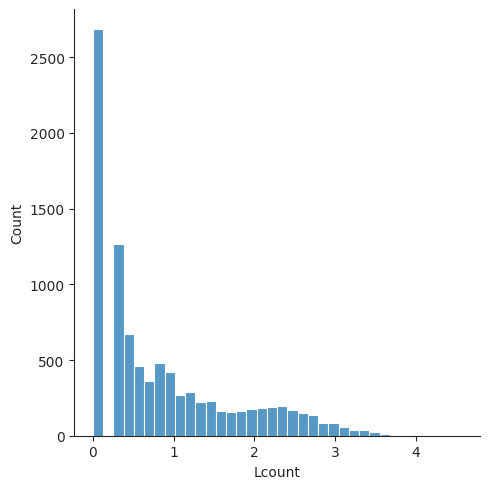

In [ ]:
sns.displot(host_taxid_counts, x='Lcount')

In [ ]:
G = nx.Graph()
for _, row in tqdm.tqdm(list(host_taxid_counts.query('Lcount > 2.0').iterrows())):
    G.add_node(row['Host_taxon'], type='Host')
    G.add_node(row['order'], c=row['class'], type='Bacteria')
    G.add_edge(row['order'], row['Host_taxon'], width=row['Lcount'])

100%|██████████| 1420/1420 [00:00<00:00, 32941.81it/s]


In [ ]:
nx.write_gml(G, '../results/2025-03-19-kraken2-mmseqs2-run/taxid-bacteria-network.gml')